In [23]:
import sys
import os
sys.path.append(os.path.abspath('..'))


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [26]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [27]:
#26 cols: engine_number, cycle, 3 settings, 21 sensors
columns = (
    ["engine_number", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

print(columns)

['engine_number', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [28]:
data_path = "../data/raw/train_FD001.txt"

df_train = pd.read_csv(
    data_path,
    sep=r'\s+',
    header=None,
    names=columns,
    engine='python'
)

print(df_train.shape)
df_train.head()

(20631, 26)


,engine_number,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [29]:
display(df_train.head())
display(df_train.tail())

,engine_number,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


,engine_number,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,21.61,551.43,2388.19,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,21.61,550.86,2388.23,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,21.61,550.94,2388.24,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,21.61,550.68,2388.25,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,21.61,550.79,2388.26,9061.48,1.3,48.20,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [30]:
#check for nulls
print(df_train.isnull().sum().sum())  #should be 0

print(df_train.duplicated().sum())

0
0


In [31]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [32]:
n_engines = df_train['engine_number'].nunique()
print(n_engines)

100


In [33]:
#lifetime per engine
df_train.groupby('engine_number')['cycle'].max().describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

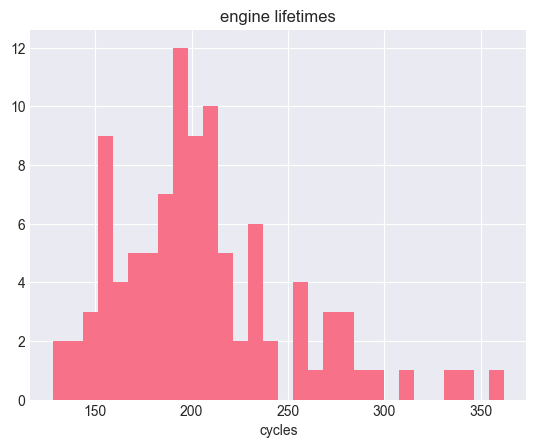

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [34]:
#how long do engines typically last?
cycles_per_engine = df_train.groupby('engine_number')['cycle'].max()

plt.hist(cycles_per_engine, bins=30)
plt.title('engine lifetimes')
plt.xlabel('cycles')
plt.show()

print(cycles_per_engine.describe())

In [35]:
engine_id = 1
engine_data = df_train[df_train['engine_number'] == engine_id]

print(len(engine_data))
engine_data.head()

192


,engine_number,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [36]:
std_dev = df_train.std().sort_values()
print(std_dev)

#anything with basically zero std is useless
low_variance_cols = std_dev[std_dev < 0.001].index.tolist()
print("\ngoing to drop these:", low_variance_cols)

sensor_19        0.000000e+00
setting_3        0.000000e+00
sensor_1         0.000000e+00
sensor_18        0.000000e+00
sensor_10        0.000000e+00
sensor_16        1.387812e-17
sensor_5         1.776400e-15
setting_2        2.930621e-04
sensor_6         1.388985e-03
setting_1        2.187313e-03
sensor_15        3.750504e-02
sensor_8         7.098548e-02
sensor_13        7.191892e-02
sensor_21        1.082509e-01
sensor_20        1.807464e-01
sensor_11        2.670874e-01
sensor_2         5.000533e-01
sensor_12        7.375534e-01
sensor_7         8.850923e-01
sensor_17        1.548763e+00
sensor_3         6.131150e+00
sensor_4         9.000605e+00
sensor_14        1.907618e+01
sensor_9         2.208288e+01
engine_number    2.922763e+01
cycle            6.888099e+01
dtype: float64

going to drop these: ['sensor_19', 'setting_3', 'sensor_1', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5', 'setting_2']


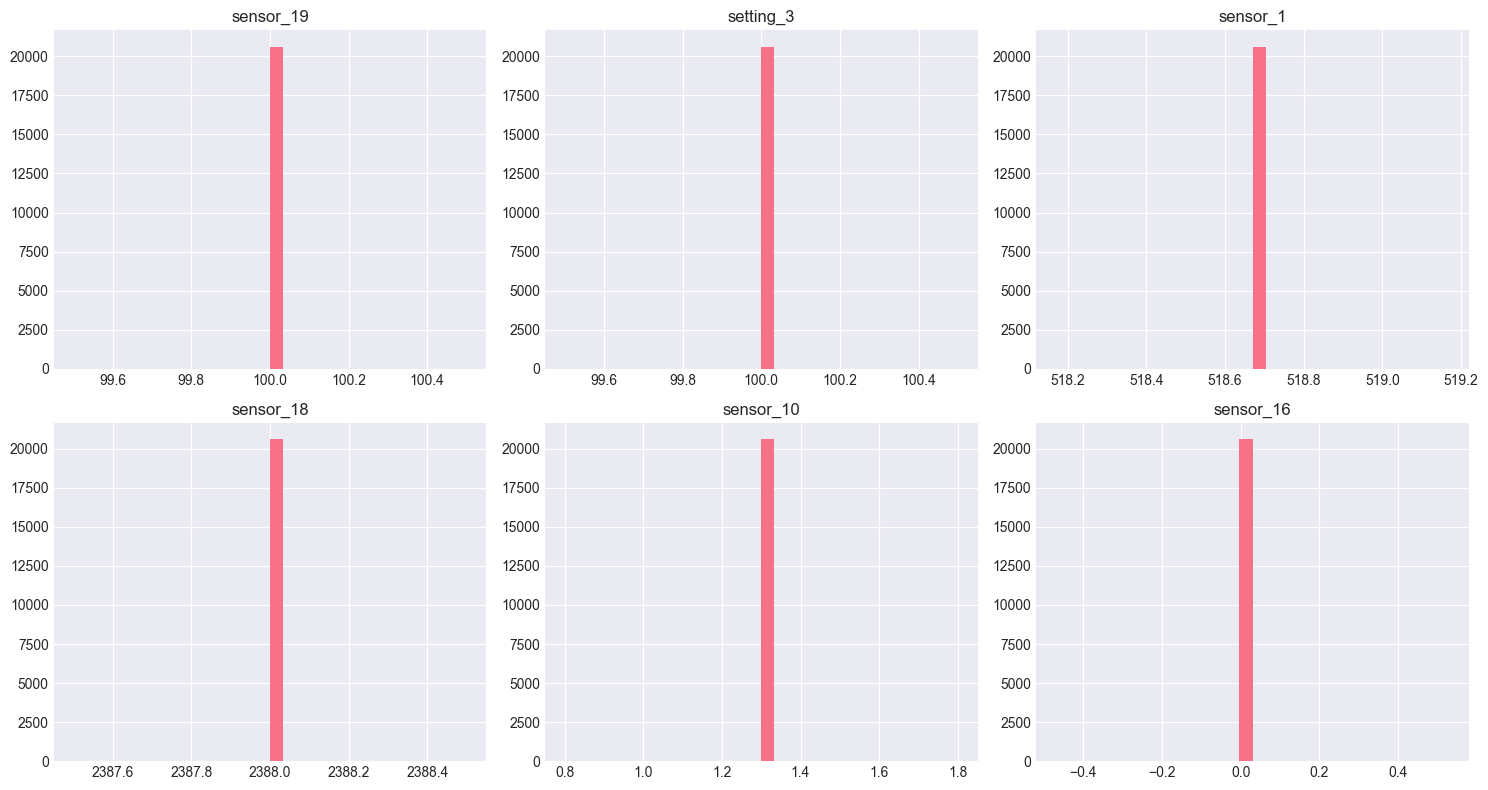

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, sensor in enumerate(low_variance_cols[:6]):
    axes[i].hist(df_train[sensor], bins=30)
    axes[i].set_title(sensor)

plt.tight_layout()
plt.savefig('../figures/eda_constant_sensors.png')
plt.show()

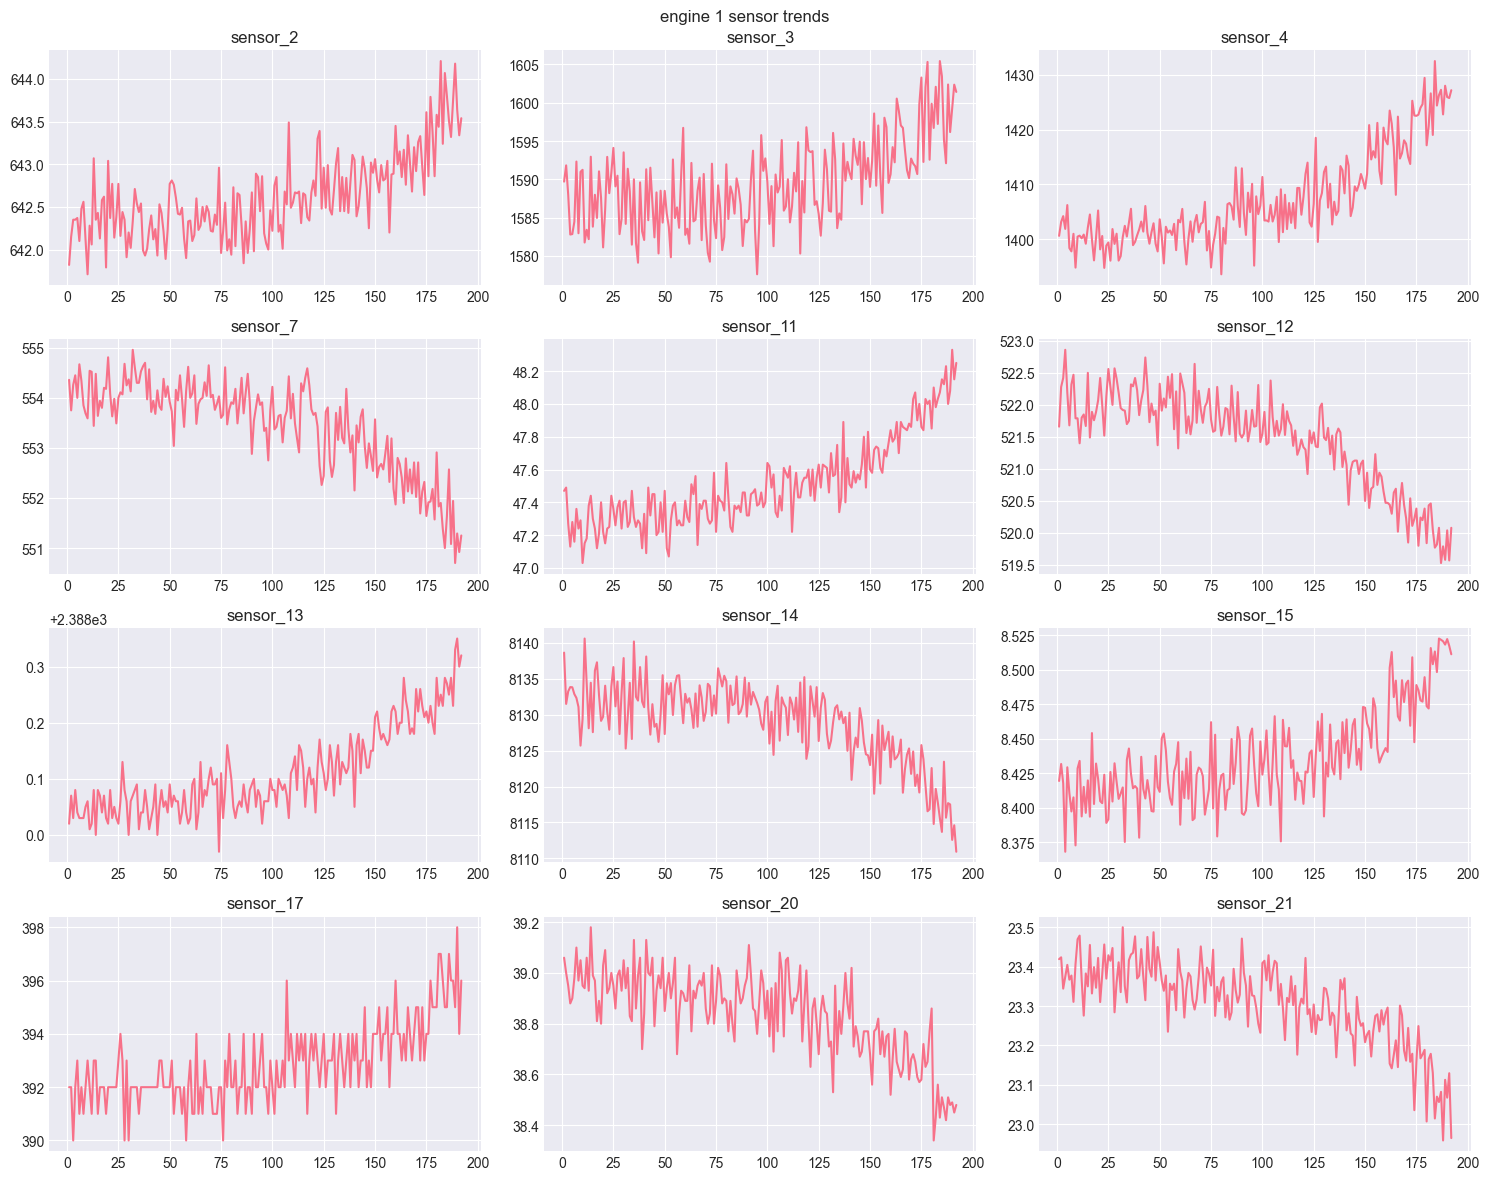

In [38]:
#which sensors actually change over time?
interesting_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 
                       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 
                       'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for i, sensor in enumerate(interesting_sensors):
    axes[i].plot(engine_data['cycle'], engine_data[sensor])
    axes[i].set_title(sensor)

plt.suptitle(f'engine {engine_id} sensor trends')
plt.tight_layout()
plt.savefig('../figures/eda_single_engine_degradation.png')
plt.show()

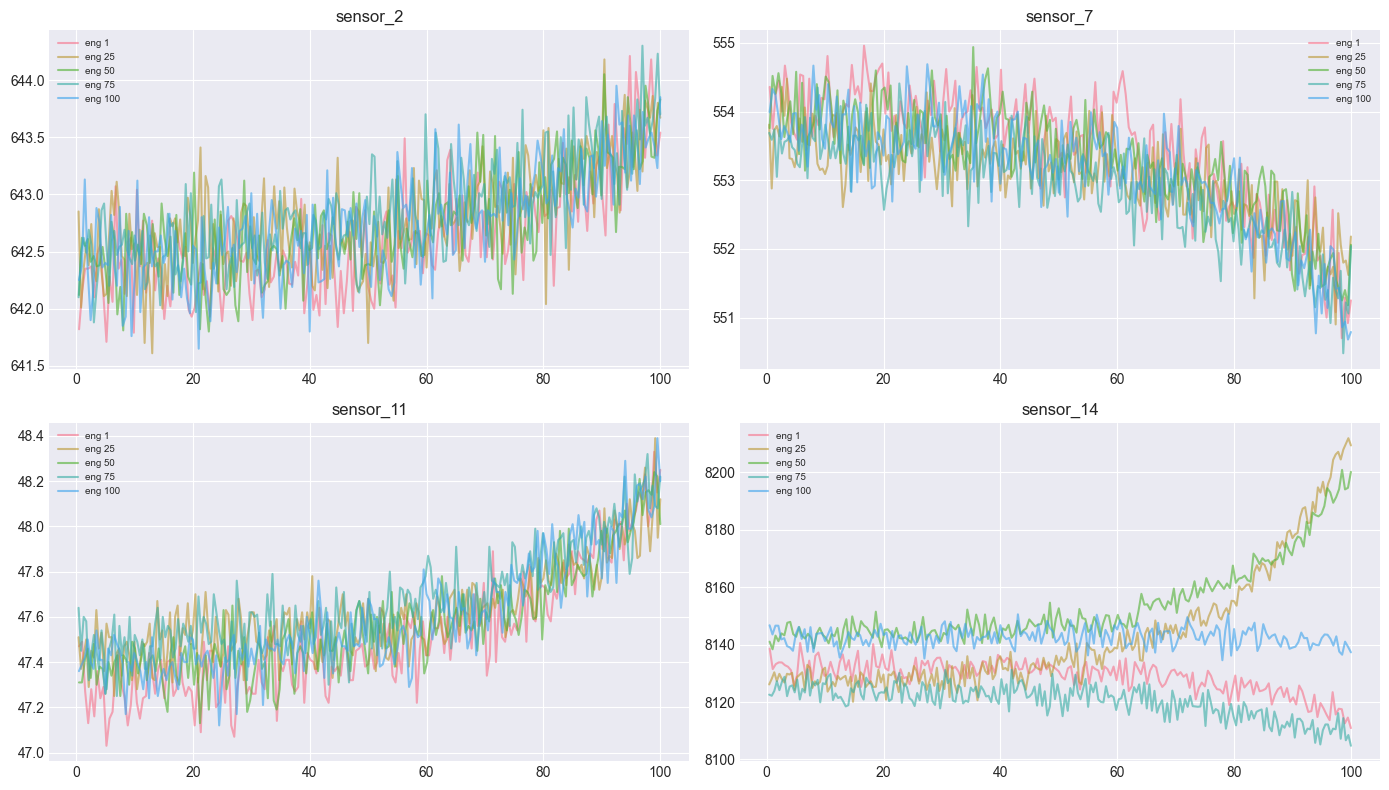

In [39]:
#do all engines degrade the same way? normalizing cycles so i can compare them
sample_engines = [1, 25, 50, 75, 100]
sensors_to_plot = ['sensor_2', 'sensor_7', 'sensor_11', 'sensor_14']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, sensor in enumerate(sensors_to_plot):
    for engine_id in sample_engines:
        edata = df_train[df_train['engine_number'] == engine_id]
        norm_cycle = edata['cycle'] / edata['cycle'].max() * 100
        axes[i].plot(norm_cycle, edata[sensor], alpha=0.6, label=f'eng {engine_id}')
    axes[i].set_title(sensor)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.savefig('../figures/eda_multi_engine_comparison.png')
plt.show()
#patterns look pretty consistent across engiines which is good

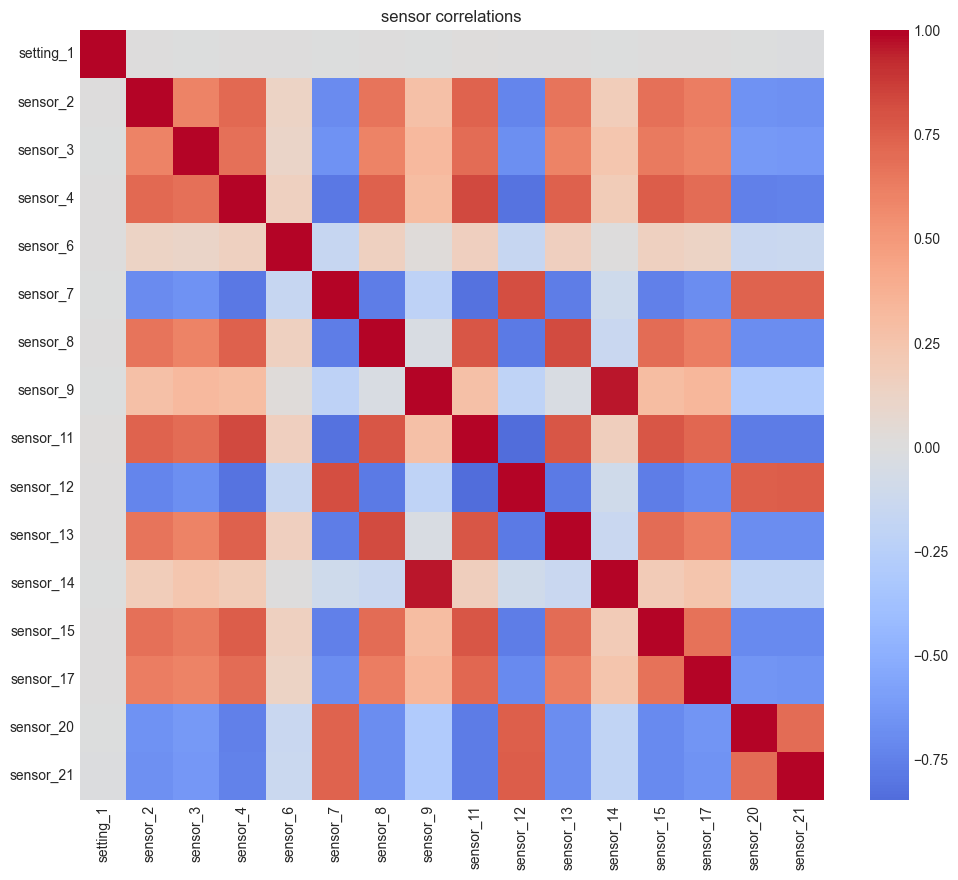

[('sensor_9', 'sensor_14', 0.9631566003059776)]


In [40]:
#select variable sensors only, drop constants and identifiers
variable_cols = [col for col in df_train.columns 
                 if col not in ['engine_number', 'cycle'] + low_variance_cols]

correlation_matrix = df_train[variable_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('sensor correlations')
plt.savefig('../figures/eda_correlation_heatmap.png')
plt.show()

# find highly correlated pairs
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr.append((correlation_matrix.columns[i], 
                            correlation_matrix.columns[j], 
                            correlation_matrix.iloc[i, j]))
print(high_corr)